# IGBT Time-Series Degradation & Breakdown Prediction

A leakage-current prediction pipeline designed for SIH predictive-maintenance use.

**Core correction:** temporal ordering is preserved throughout. There is no random train/test split and no future-information leakage in lag/rolling features.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

df = pd.read_csv("/Users/samarth/Documents/ts_breakdown/Breakdown_timeseries_microampere.csv")

time_col = "time_minutes"
voltage_col = "Collector_Emitter_Voltage_Vce"
current_col = "Leakage_Current_Ic_microampere"

df = df[[time_col, voltage_col, current_col]].sort_values(time_col).reset_index(drop=True)

print("Shape:", df.shape)
display(df.head())
display(df.describe())

Shape: (3790, 3)


,time_minutes,Collector_Emitter_Voltage_Vce,Leakage_Current_Ic_microampere
0,0,2.020181,0.005886
1,30,2.040083,0.005928
2,60,2.060686,0.005913
3,90,2.080598,0.005896
4,120,2.100827,0.006044


,time_minutes,Collector_Emitter_Voltage_Vce,Leakage_Current_Ic_microampere
count,3790.000000,3790.000000,3790.000000
mean,56835.000000,3.883881,71.072029
std,32826.692645,0.999526,107.322956
min,0.000000,2.000283,0.004430
25%,28417.500000,3.005360,0.009564
50%,56835.000000,4.010279,0.367500
75%,85252.500000,4.935367,223.395350
max,113670.000000,5.205097,250.025400


In [4]:
print("Missing values:")
print(df.isna().sum())
print("Duplicate timestamps:", df[time_col].duplicated().sum())
print("Time-step distribution:")
print(df[time_col].diff().dropna().value_counts().head())

Missing values:
time_minutes                      0
Collector_Emitter_Voltage_Vce     0
Leakage_Current_Ic_microampere    0
dtype: int64
Duplicate timestamps: 0
Time-step distribution:
time_minutes
30.0    3789
Name: count, dtype: int64


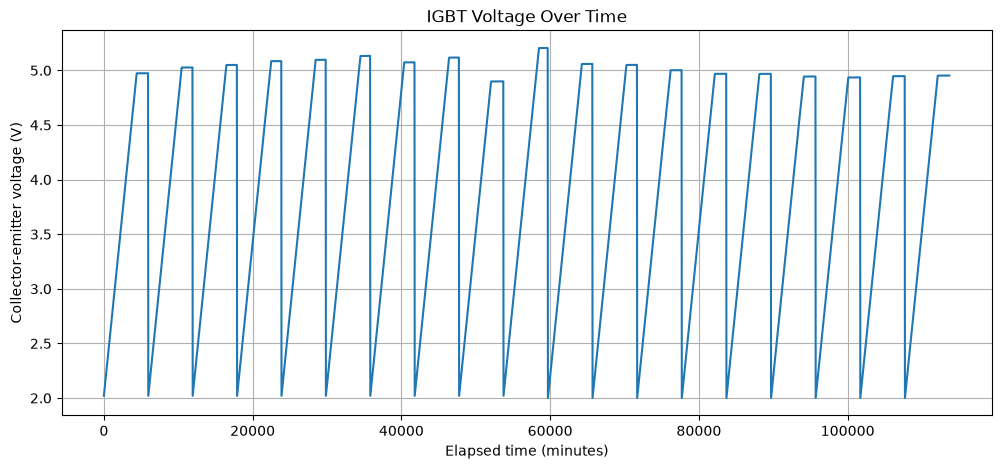

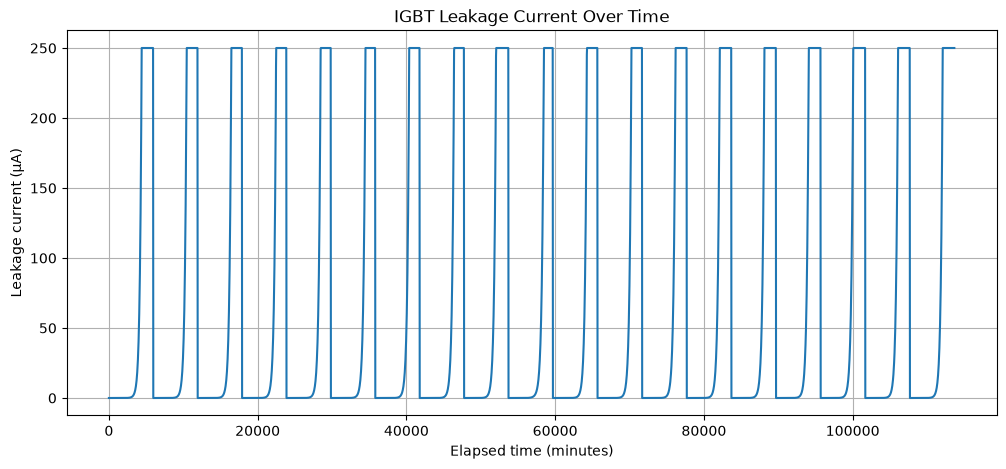

In [5]:
fig = plt.figure(figsize=(12, 5))
plt.plot(df[time_col], df[voltage_col])
plt.xlabel("Elapsed time (minutes)")
plt.ylabel("Collector-emitter voltage (V)")
plt.title("IGBT Voltage Over Time")
plt.grid(True)
plt.show()

fig = plt.figure(figsize=(12, 5))
plt.plot(df[time_col], df[current_col])
plt.xlabel("Elapsed time (minutes)")
plt.ylabel("Leakage current (µA)")
plt.title("IGBT Leakage Current Over Time")
plt.grid(True)
plt.show()

## Temporal feature engineering

All lag and rolling features use **only earlier observations**. Rolling statistics are shifted before calculation so the current target cannot leak into its own features.

In [6]:
data = df.copy()

for lag in [1, 2, 3, 6, 12]:
    data[f"voltage_lag_{lag}"] = data[voltage_col].shift(lag)
    data[f"current_lag_{lag}"] = data[current_col].shift(lag)

past_current = data[current_col].shift(1)
past_voltage = data[voltage_col].shift(1)

for window in [3, 6, 12, 24]:
    data[f"current_roll_mean_{window}"] = past_current.rolling(window).mean()
    data[f"current_roll_std_{window}"] = past_current.rolling(window).std()
    data[f"voltage_roll_mean_{window}"] = past_voltage.rolling(window).mean()
    data[f"voltage_roll_std_{window}"] = past_voltage.rolling(window).std()

data["voltage_delta"] = data[voltage_col] - data[voltage_col].shift(1)
data["current_delta"] = data[current_col] - data[current_col].shift(1)
data["voltage_current_product"] = data[voltage_col] * data[current_col]

data = data.dropna().reset_index(drop=True)

print("Feature-engineered shape:", data.shape)
display(data.head())

Feature-engineered shape: (3766, 32)


,time_minutes,Collector_Emitter_Voltage_Vce,Leakage_Current_Ic_microampere,voltage_lag_1,current_lag_1,voltage_lag_2,current_lag_2,voltage_lag_3,current_lag_3,voltage_lag_6,...,current_roll_std_12,voltage_roll_mean_12,voltage_roll_std_12,current_roll_mean_24,current_roll_std_24,voltage_roll_mean_24,voltage_roll_std_24,voltage_delta,current_delta,voltage_current_product
0,720,2.502876,0.007109,2.482916,0.006997,2.462646,0.006943,2.442444,0.006909,2.382347,...,0.000192,2.372158,0.072491,0.006432,0.000361,2.251493,0.142195,0.019960,0.000113,0.017794
1,750,2.522765,0.007157,2.502876,0.007109,2.482916,0.006997,2.462646,0.006943,2.402278,...,0.000193,2.392245,0.072536,0.006483,0.000366,2.271606,0.142192,0.019889,0.000047,0.018054
2,780,2.542662,0.007191,2.522765,0.007157,2.502876,0.007109,2.482916,0.006997,2.422204,...,0.000187,2.412331,0.072524,0.006534,0.000371,2.291717,0.142157,0.019897,0.000034,0.018284
3,810,2.563241,0.007301,2.542662,0.007191,2.522765,0.007157,2.502876,0.007109,2.442444,...,0.000185,2.432416,0.072458,0.006588,0.000370,2.311800,0.142145,0.020579,0.000111,0.018715
4,840,2.583183,0.007344,2.563241,0.007301,2.542662,0.007191,2.522765,0.007157,2.462646,...,0.000195,2.452554,0.072437,0.006646,0.000367,2.331910,0.142154,0.019942,0.000042,0.018970


In [7]:
# Chronological 80/20 split — the test set is the future period.
target = current_col
feature_cols = [c for c in data.columns if c not in [target, time_col]]

split_idx = int(len(data) * 0.80)

train = data.iloc[:split_idx].copy()
test = data.iloc[split_idx:].copy()

X_train, y_train = train[feature_cols], train[target]
X_test, y_test = test[feature_cols], test[target]

print(f"Train: {train[time_col].min()}–{train[time_col].max()} min")
print(f"Test : {test[time_col].min()}–{test[time_col].max()} min")
print("X_train:", X_train.shape, "X_test:", X_test.shape)

Train: 720–91050 min
Test : 91080–113670 min
X_train: (3012, 30) X_test: (754, 30)


## Model

Gradient Boosting Regression provides a nonlinear baseline for predicting future leakage current from historical electrical behavior.

In [8]:
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("regressor", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        random_state=42
    ))
])

model.fit(X_train, y_train)
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print(f"MAE  : {mae:.6f} µA")
print(f"RMSE : {rmse:.6f} µA")
print(f"R²   : {r2:.6f}")

MAE  : 0.088069 µA
RMSE : 0.280492 µA
R²   : 0.999994


In [9]:
# Proper time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

cv_scores = cross_val_score(
    model, X_train, y_train,
    cv=tscv,
    scoring="neg_root_mean_squared_error"
)

print("Fold RMSE:", -cv_scores)
print(f"Mean CV RMSE: {-cv_scores.mean():.6f} µA")

Fold RMSE: [0.88156561 0.27048375 0.93529522 0.31337478 0.43388872]
Mean CV RMSE: 0.566922 µA


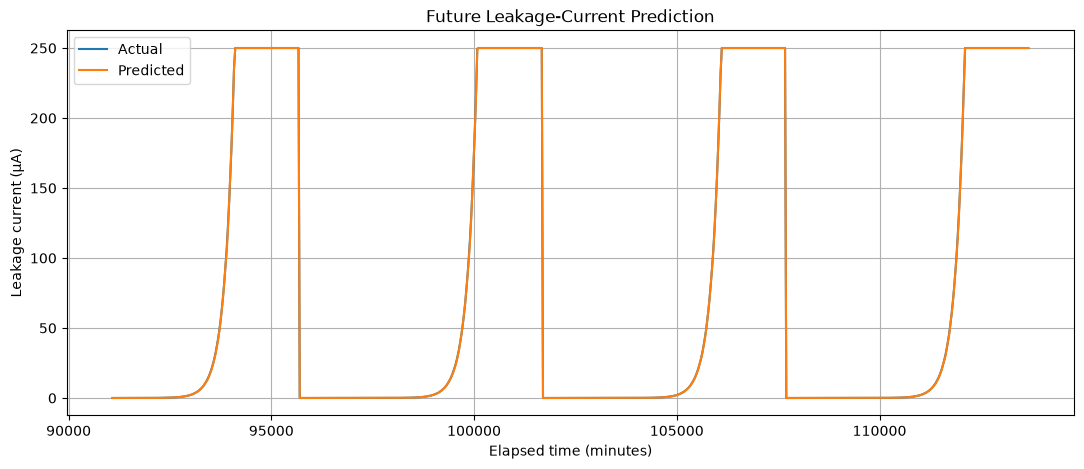

In [10]:
fig = plt.figure(figsize=(13, 5))
plt.plot(test[time_col], y_test.values, label="Actual")
plt.plot(test[time_col], pred, label="Predicted")
plt.xlabel("Elapsed time (minutes)")
plt.ylabel("Leakage current (µA)")
plt.title("Future Leakage-Current Prediction")
plt.legend()
plt.grid(True)
plt.show()

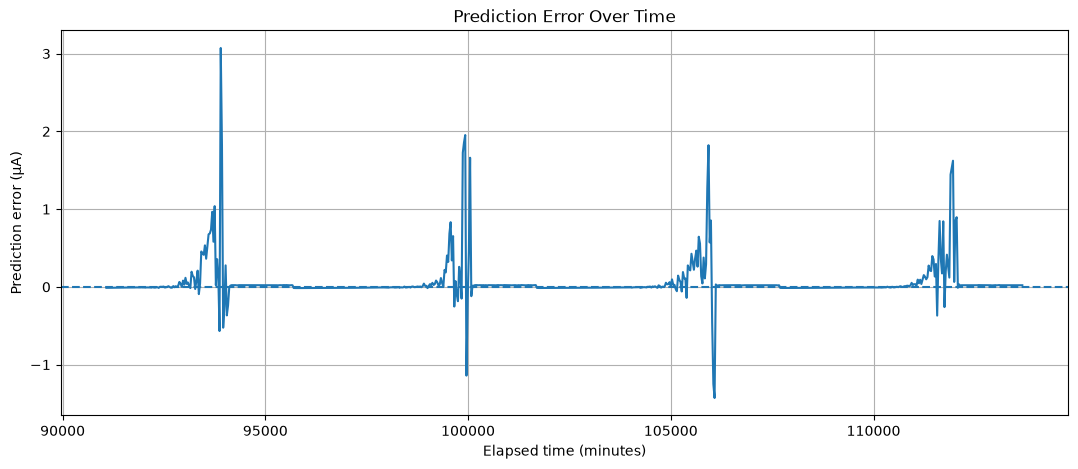

In [11]:
errors = y_test.values - pred

fig = plt.figure(figsize=(13, 5))
plt.plot(test[time_col], errors)
plt.axhline(0, linestyle="--")
plt.xlabel("Elapsed time (minutes)")
plt.ylabel("Prediction error (µA)")
plt.title("Prediction Error Over Time")
plt.grid(True)
plt.show()

voltage_current_product    9.777862e-01
current_delta              5.645302e-03
current_roll_mean_3        3.962113e-03
current_roll_mean_6        2.977786e-03
current_lag_1              2.028307e-03
current_lag_3              1.978714e-03
current_lag_2              1.531188e-03
current_roll_mean_12       1.446690e-03
current_lag_6              1.201291e-03
current_roll_mean_24       5.709956e-04
current_roll_std_3         3.149214e-04
current_roll_std_24        2.802121e-04
current_roll_std_6         1.583601e-04
current_roll_std_12        1.164760e-04
current_lag_12             5.871183e-07
dtype: float64

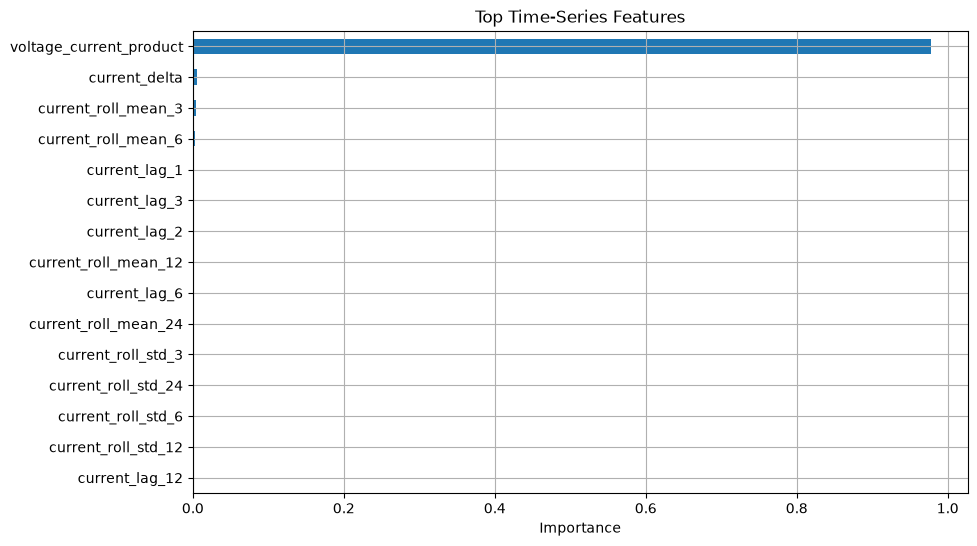

In [12]:
importance = pd.Series(
    model.named_steps["regressor"].feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

display(importance.head(15))

fig = plt.figure(figsize=(10, 6))
importance.head(15).sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Top Time-Series Features")
plt.grid(True)
plt.show()

## SIH deployment interpretation

**Sequential sensor data → temporal features → chronological training → future prediction → residual monitoring → degradation/anomaly warning**

The prediction residual can be monitored as:

`residual = actual leakage current − predicted leakage current`

A sustained increase in leakage current or persistent residual drift can become an early-warning indicator.

**Data note:** the 30-minute `time_minutes` field is a constructed elapsed-time index. Do not describe it as the original experimental sampling interval unless the source documentation confirms that.